# 02 — Baseline Model\n\nTrain a U-Net (ResNet-34) on Iowa, evaluate on both Iowa val and Niger eval to reproduce the domain shift.\n\nExpecting source mIoU around 0.5-0.7 and a big drop on target. Shrub is absent from Iowa so target shrub IoU will be ~0 by construction.

In [1]:
import sys, os
sys.path.insert(0, "..")
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from torch.utils.data import DataLoader
from pathlib import Path

from src.data_acquisition import CLASS_NAMES, NUM_CLASSES, NODATA_LABEL
from src.dataset import LandCoverDataset, load_norm_stats
from src.training import (
    create_model, compute_class_weights, TrainConfig,
    train_model, evaluate, get_device, SegmentationMetrics,
)

torch.manual_seed(42)
np.random.seed(42)

SOURCE_DIR = Path("../data/source")
TARGET_DIR = Path("../data/target")
CHECKPOINT_DIR = Path("../checkpoints")

device = get_device("mps")
print(f"Using device: {device}")

Using device: mps


## Load splits and create datasets

In [2]:
with open(SOURCE_DIR / "splits.json") as f:
    src_splits = json.load(f)
with open(TARGET_DIR / "splits.json") as f:
    tgt_splits = json.load(f)

mean, std = load_norm_stats(SOURCE_DIR / "norm_stats.json")

print(f"Source train: {len(src_splits['train'])} chips")
print(f"Source val:   {len(src_splits['val'])} chips (spatial block split)")
print(f"Target eval:  {len(tgt_splits['eval'])} chips")

BATCH_SIZE = 8
NUM_WORKERS = 8

train_ds = LandCoverDataset(SOURCE_DIR, src_splits["train"], mean, std, augment=True)
val_ds   = LandCoverDataset(SOURCE_DIR, src_splits["val"],   mean, std, augment=False)
tgt_ds   = LandCoverDataset(TARGET_DIR, tgt_splits["eval"],  mean, std, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
tgt_loader   = DataLoader(tgt_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

img, lbl = train_ds[0]
print(f"\nImage shape: {img.shape}, dtype: {img.dtype}")
print(f"Label shape: {lbl.shape}, dtype: {lbl.dtype}, unique: {lbl.unique().tolist()}")

Source train: 255 chips
Source val:   45 chips (spatial block split)
Target eval:  60 chips

Image shape: torch.Size([5, 256, 256]), dtype: torch.float32
Label shape: torch.Size([256, 256]), dtype: torch.int64, unique: [0, 2, 3, 4, 5]


## Augmentation sanity check

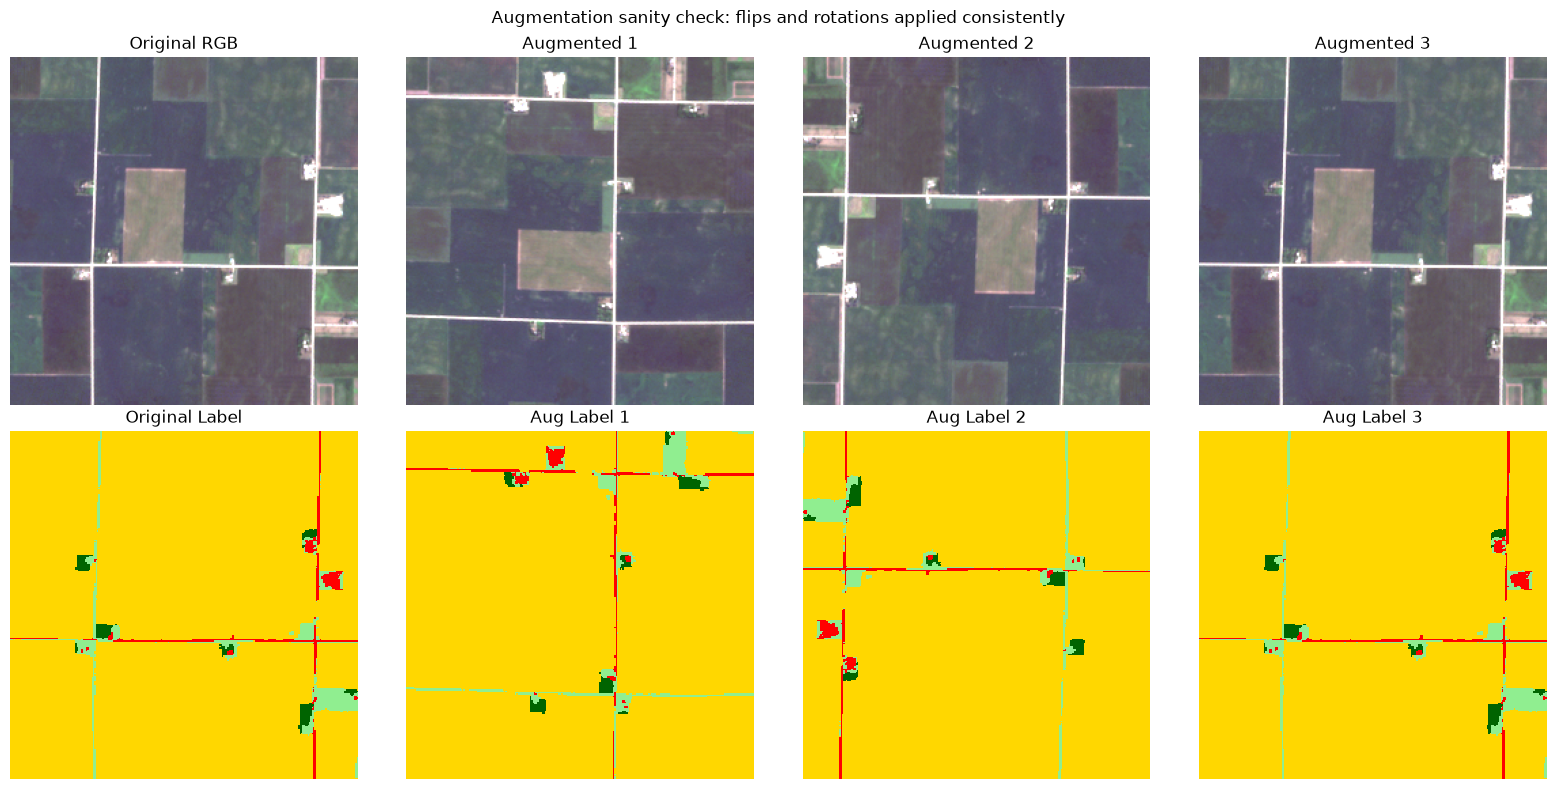

In [3]:
CLASS_COLORS = ["#006400", "#8B4513", "#90EE90", "#FFD700", "#FF0000", "#D2B48C", "#0000FF"]
cmap = mcolors.ListedColormap(CLASS_COLORS)
norm_cm = mcolors.BoundaryNorm(np.arange(NUM_CLASSES + 1) - 0.5, NUM_CLASSES)

# Show original and augmented side-by-side
aug_ds = LandCoverDataset(SOURCE_DIR, src_splits["train"][:1], mean, std, augment=True)
noaug_ds = LandCoverDataset(SOURCE_DIR, src_splits["train"][:1], mean, std, augment=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
orig_img, orig_lbl = noaug_ds[0]
axes[0, 0].imshow(np.clip(orig_img[[2,1,0]].numpy().transpose(1,2,0) * 0.3 + 0.5, 0, 1))
axes[0, 0].set_title("Original RGB")
axes[1, 0].imshow(orig_lbl.numpy(), cmap=cmap, norm=norm_cm, interpolation="nearest")
axes[1, 0].set_title("Original Label")

for i in range(1, 4):
    aug_img, aug_lbl = aug_ds[0]
    axes[0, i].imshow(np.clip(aug_img[[2,1,0]].numpy().transpose(1,2,0) * 0.3 + 0.5, 0, 1))
    axes[0, i].set_title(f"Augmented {i}")
    axes[1, i].imshow(aug_lbl.numpy(), cmap=cmap, norm=norm_cm, interpolation="nearest")
    axes[1, i].set_title(f"Aug Label {i}")

for ax in axes.flat:
    ax.axis("off")
fig.suptitle("Augmentation sanity check: flips and rotations applied consistently", fontsize=12)
plt.tight_layout()
plt.show()

## Create model and train

In [4]:
from src.data_acquisition import compute_dataset_stats

src_stats = compute_dataset_stats(SOURCE_DIR, src_splits["train"])
class_weights = compute_class_weights(src_stats["class_freq"], max_weight=10.0)
print("Class weights:")
for n, f, w in zip(CLASS_NAMES, src_stats["class_freq"], class_weights):
    print(f"  {n:6s}: freq={f:.3f}, weight={w:.2f}")

model = create_model(encoder_name="resnet34", in_channels=5, num_classes=NUM_CLASSES)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"\nModel parameters: {n_params:.1f}M")

Class weights:
  tree  : freq=0.085, weight=1.25
  shrub : freq=0.000, weight=1.00
  grass : freq=0.116, weight=1.08
  crop  : freq=0.758, weight=0.17
  built : freq=0.039, weight=1.25
  bare  : freq=0.001, weight=1.00
  water : freq=0.002, weight=1.25



Model parameters: 24.4M


In [5]:
config = TrainConfig(
    epochs=30,
    batch_size=BATCH_SIZE,
    lr=3e-4,
    weight_decay=1e-4,
    num_workers=NUM_WORKERS,
    encoder_name="resnet34",
    device="mps",
    save_dir=str(CHECKPOINT_DIR),
)

history = train_model(model, train_loader, val_loader, config, class_weights=class_weights)
print(f"\nBest val mIoU: {history['best_miou']:.4f} at epoch {history['best_epoch']}")

Train 1/30:   0%|          | 0/31 [00:00<?, ?it/s]

Train 1/30:   0%|          | 0/31 [00:02<?, ?it/s, loss=2.1428]

Train 1/30:   3%|▎         | 1/31 [00:02<01:18,  2.60s/it, loss=2.1428]

Train 1/30:   3%|▎         | 1/31 [00:03<01:18,  2.60s/it, loss=2.0324]

Train 1/30:   6%|▋         | 2/31 [00:03<00:40,  1.39s/it, loss=2.0324]

...

Eval:  83%|████████▎ | 5/6 [00:02<00:00,  2.94it/s]

Eval:  83%|████████▎ | 5/6 [00:20<00:00,  2.94it/s]

Epoch 30/30 | train_loss=0.4101 | val_loss=0.4738 | val_mIoU=0.5610 (over 6 classes) | lr=1.00e-06 | 81.4s
  Per-class: tree=0.691 | shrub=N/A | grass=0.571 | crop=0.855 | built=0.422 | bare=0.000 | water=0.827


  ** New best (mIoU=0.5610) **



Best val mIoU: 0.5610 at epoch 30


## Training curves

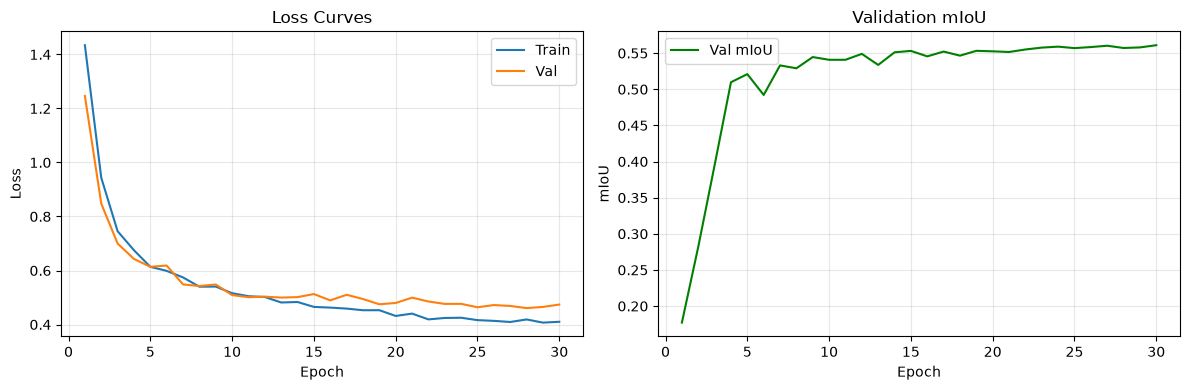

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history["train_losses"]) + 1)
ax1.plot(epochs, history["train_losses"], label="Train")
ax1.plot(epochs, history["val_losses"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss Curves")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history["val_mious"], label="Val mIoU", color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("mIoU"); ax2.set_title("Validation mIoU")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../report/figures/02_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Evaluate: Source val vs Target eval

In [7]:
# Load best model
model.load_state_dict(torch.load(CHECKPOINT_DIR / "best_model.pth", map_location=device, weights_only=True))
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights.to(device), ignore_index=NODATA_LABEL
)

# Source val
src_loss, src_iou, src_miou, src_cm, src_present = evaluate(model, val_loader, criterion, device)
print(f"Source val -- mIoU: {src_miou:.4f} (over {len(src_present)} classes: {[CLASS_NAMES[i] for i in src_present]})")
print("Per-class IoU:")
for i, (name, iou) in enumerate(zip(CLASS_NAMES, src_iou)):
    status = f"{iou:.4f}" if not np.isnan(iou) else "N/A (absent)"
    print(f"  {name}: {status}")

print()

# Target eval
tgt_loss, tgt_iou, tgt_miou, tgt_cm, tgt_present = evaluate(model, tgt_loader, criterion, device)
print(f"Target eval -- mIoU: {tgt_miou:.4f} (over {len(tgt_present)} classes: {[CLASS_NAMES[i] for i in tgt_present]})")
print("Per-class IoU:")
for i, (name, iou) in enumerate(zip(CLASS_NAMES, tgt_iou)):
    status = f"{iou:.4f}" if not np.isnan(iou) else "N/A (absent)"
    print(f"  {name}: {status}")

# Domain shift drop
drop = src_miou - tgt_miou
print(f"\n*** Domain shift drop: {drop:.4f} ({drop*100:.1f} percentage points) ***")

# Also compute mIoU over shared classes only
shared = set(src_present) & set(tgt_present)
shared_src = np.nanmean([src_iou[i] for i in shared]) if shared else 0
shared_tgt = np.nanmean([tgt_iou[i] for i in shared]) if shared else 0
shared_drop = shared_src - shared_tgt
print(f"\nShared classes ({[CLASS_NAMES[i] for i in sorted(shared)]}): "
      f"src={shared_src:.4f}, tgt={shared_tgt:.4f}, drop={shared_drop:.4f} ({shared_drop*100:.1f} pts)")
print("(Shared-class drop isolates covariate shift from label shift)")

Eval:   0%|          | 0/6 [00:00<?, ?it/s]

Eval:  17%|█▋        | 1/6 [00:02<00:11,  2.32s/it]

Eval:  50%|█████     | 3/6 [00:02<00:01,  1.52it/s]

Eval:  83%|████████▎ | 5/6 [00:02<00:00,  2.85it/s]

Eval:  83%|████████▎ | 5/6 [00:16<00:00,  2.85it/s]

...

Eval:  38%|███▊      | 3/8 [00:02<00:03,  1.39it/s]

Eval:  62%|██████▎   | 5/8 [00:02<00:01,  2.62it/s]

Eval:  88%|████████▊ | 7/8 [00:03<00:00,  3.94it/s]

Eval:  88%|████████▊ | 7/8 [00:13<00:00,  3.94it/s]

Target eval -- mIoU: 0.0634 (over 7 classes: ['tree', 'shrub', 'grass', 'crop', 'built', 'bare', 'water'])
Per-class IoU:
  tree: 0.0066
  shrub: 0.0000
  grass: 0.1963
  crop: 0.0392
  built: 0.1897
  bare: 0.0000
  water: 0.0117

*** Domain shift drop: 0.4976 (49.8 percentage points) ***

Shared classes (['tree', 'grass', 'crop', 'built', 'bare', 'water']): src=0.5610, tgt=0.0739, drop=0.4871 (48.7 pts)
(Shared-class drop isolates covariate shift from label shift)


## Figure 1a: Per-class IoU comparison

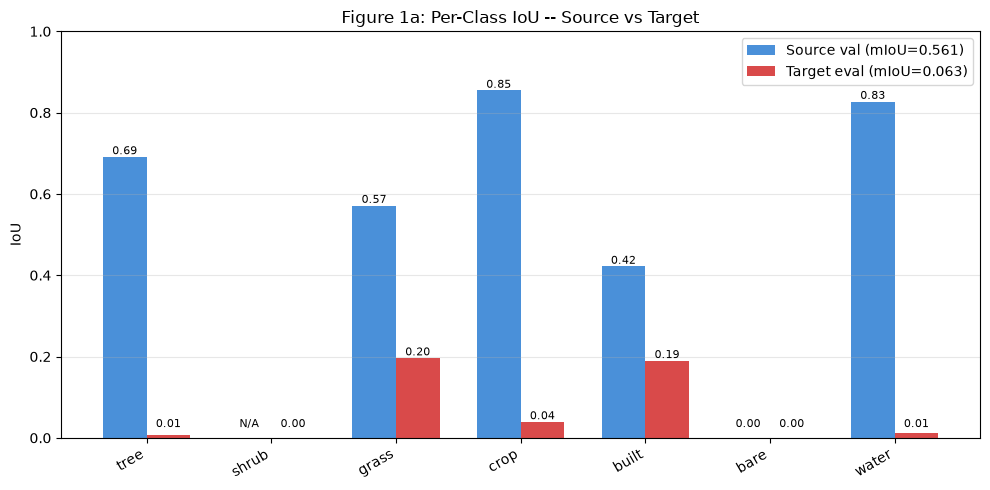

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(NUM_CLASSES)
width = 0.35

# Replace NaN with 0 for plotting
src_iou_plot = np.nan_to_num(src_iou, nan=0.0)
tgt_iou_plot = np.nan_to_num(tgt_iou, nan=0.0)

bars1 = ax.bar(x - width/2, src_iou_plot, width, label=f"Source val (mIoU={src_miou:.3f})", color="#4A90D9")
bars2 = ax.bar(x + width/2, tgt_iou_plot, width, label=f"Target eval (mIoU={tgt_miou:.3f})", color="#D94A4A")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_ylabel("IoU")
ax.set_title("Figure 1a: Per-Class IoU -- Source vs Target")
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

for bars, ious in [(bars1, src_iou), (bars2, tgt_iou)]:
    for bar, iou in zip(bars, ious):
        h = bar.get_height()
        label = f"{iou:.2f}" if not np.isnan(iou) else "N/A"
        ax.annotate(label, xy=(bar.get_x() + bar.get_width()/2, max(h, 0.02)),
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("../report/figures/02_per_class_iou.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 1b: Confusion matrices (row-normalized)

/var/folders/g3/c_mlx1gn2dd8y29m20s40fcr0000gp/T/ipykernel_95965/3014681567.py:3: RuntimeWarning: invalid value encountered in divide
  cm_norm = np.where(row_sums > 0, cm / row_sums, 0.0)
/var/folders/g3/c_mlx1gn2dd8y29m20s40fcr0000gp/T/ipykernel_95965/3014681567.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


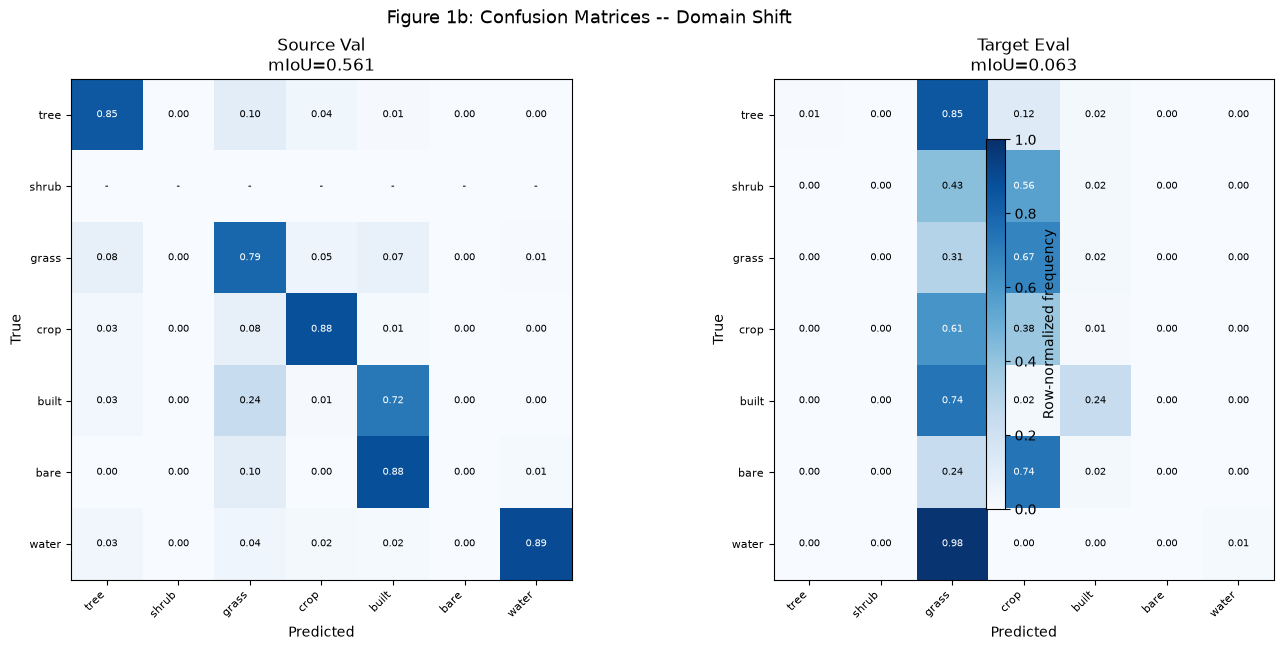

In [9]:
def plot_confusion_matrix(cm, ax, title, class_names):
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_sums > 0, cm / row_sums, 0.0)

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            val = cm_norm[i, j]
            if row_sums[i, 0] == 0:
                text = "-"
            else:
                text = f"{val:.2f}"
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, text, ha="center", va="center", fontsize=7, color=color)
    return im


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plot_confusion_matrix(src_cm, ax1, f"Source Val\nmIoU={src_miou:.3f}", CLASS_NAMES)
im = plot_confusion_matrix(tgt_cm, ax2, f"Target Eval\nmIoU={tgt_miou:.3f}", CLASS_NAMES)

fig.colorbar(im, ax=[ax1, ax2], shrink=0.8, label="Row-normalized frequency")
fig.suptitle("Figure 1b: Confusion Matrices -- Domain Shift", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../report/figures/02_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Save results

In [10]:
results = {
    "source_val": {
        "miou": float(src_miou),
        "loss": float(src_loss),
        "present_classes": [CLASS_NAMES[i] for i in src_present],
        "per_class_iou": {n: (float(v) if not np.isnan(v) else None) for n, v in zip(CLASS_NAMES, src_iou)},
    },
    "target_eval": {
        "miou": float(tgt_miou),
        "loss": float(tgt_loss),
        "present_classes": [CLASS_NAMES[i] for i in tgt_present],
        "per_class_iou": {n: (float(v) if not np.isnan(v) else None) for n, v in zip(CLASS_NAMES, tgt_iou)},
    },
    "drop_points": float(drop),
    "shared_classes_drop": float(shared_drop),
    "shared_classes": [CLASS_NAMES[i] for i in sorted(shared)],
    "config": {
        "encoder": config.encoder_name,
        "epochs": config.epochs,
        "lr": config.lr,
        "batch_size": config.batch_size,
        "best_epoch": history["best_epoch"],
    },
}

with open(CHECKPOINT_DIR / "baseline_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Results saved to", CHECKPOINT_DIR / "baseline_results.json")
print(json.dumps(results, indent=2))

Results saved to ../checkpoints/baseline_results.json
{
  "source_val": {
    "miou": 0.5609929633457895,
    "loss": 0.473840852578481,
    "present_classes": [
      "tree",
      "grass",
      "crop",
      "built",
      "bare",
      "water"
    ],
    "per_class_iou": {
      "tree": 0.6911465372051018,
      "shrub": null,
      "grass": 0.5714834551198188,
      "crop": 0.8545288136758316,
      "built": 0.4216048118902827,
      "bare": 0.0,
      "water": 0.8271941621837019
    }
  },
  "target_eval": {
    "miou": 0.06337853746945186,
    "loss": 3.2934924960136414,
    "present_classes": [
      "tree",
      "shrub",
      "grass",
      "crop",
      "built",
      "bare",
      "water"
    ],
    "per_class_iou": {
      "tree": 0.006605706596532004,
      "shrub": 0.0,
      "grass": 0.19632617272804284,
      "crop": 0.03923832217246621,
      "built": 0.18974000843845024,
      "bare": 0.0,
      "water": 0.011739552350671789
    }
  },
  "drop_points": 0.49761442587

## Qualitative predictions: Source vs Target

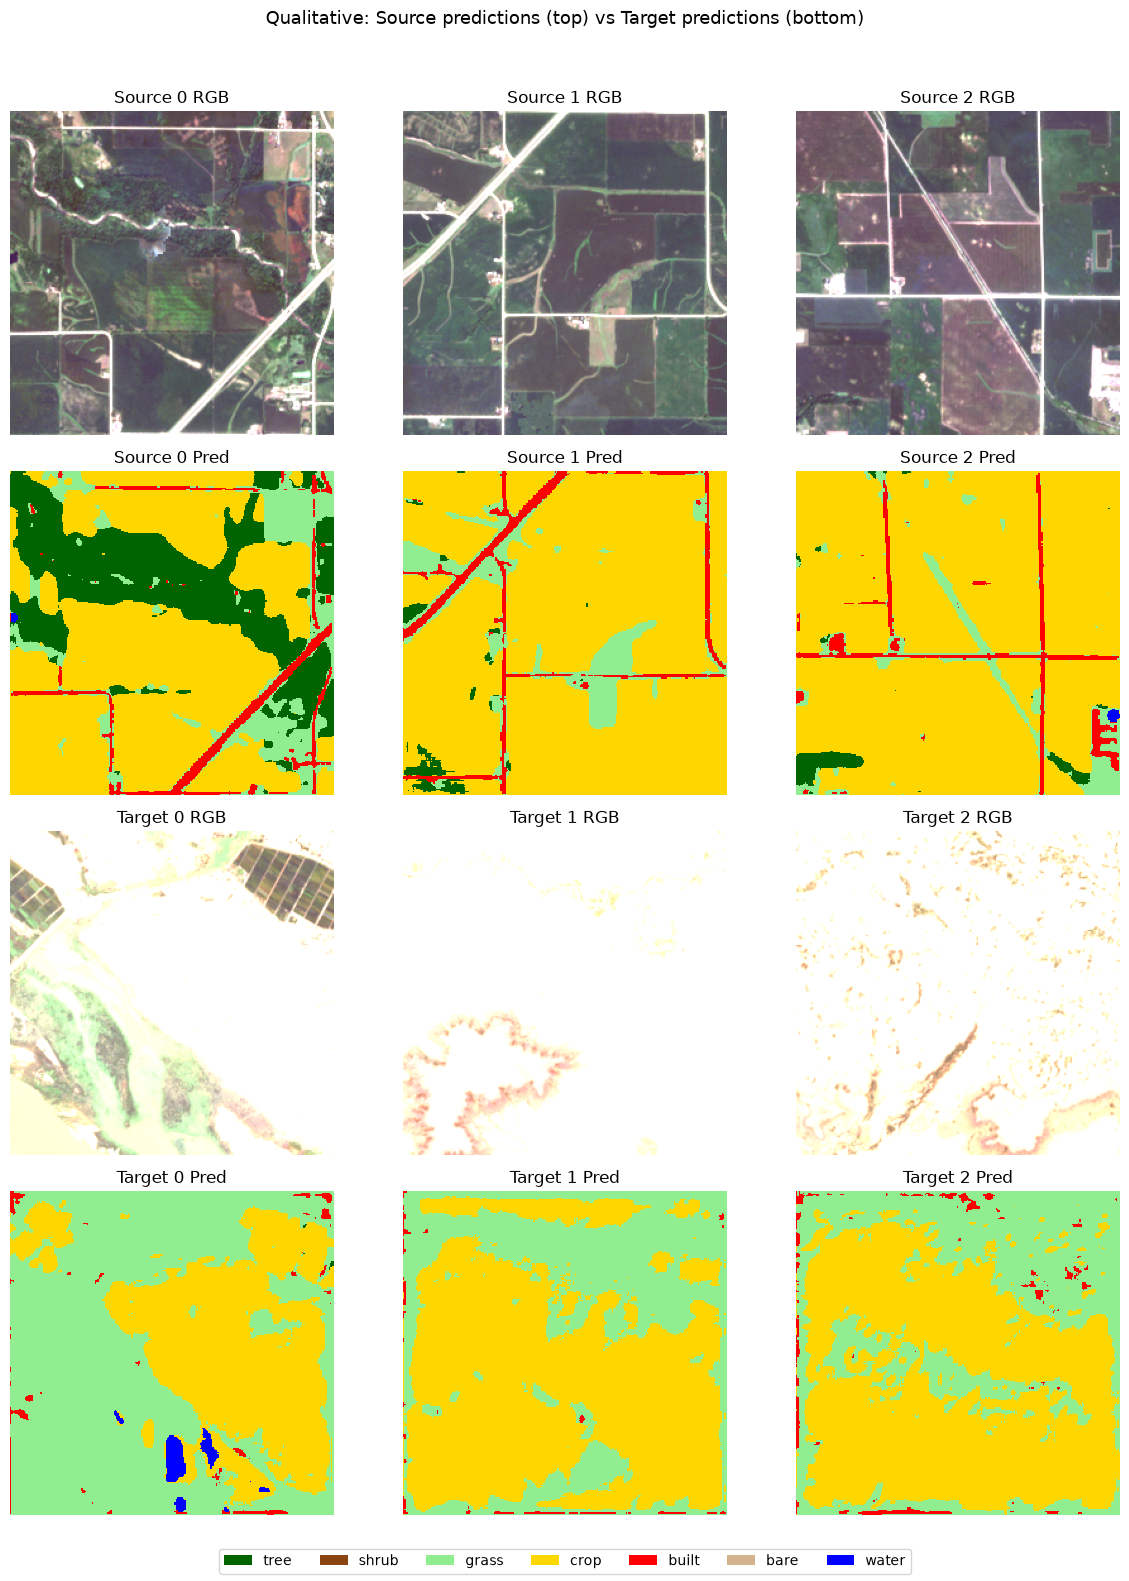

In [11]:
model.eval()
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

# 3 source val samples: RGB, GT, Prediction
for col in range(3):
    idx = col * (len(val_ds) // 3)
    img, lbl = val_ds[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(1).squeeze().cpu().numpy()

    rgb = np.clip(img[[2,1,0]].numpy().transpose(1,2,0) * 0.3 + 0.5, 0, 1)
    axes[0, col].imshow(rgb)
    axes[0, col].set_title(f"Source {col} RGB")
    axes[1, col].imshow(pred, cmap=cmap, norm=norm_cm, interpolation="nearest")
    axes[1, col].set_title(f"Source {col} Pred")

# 3 target eval samples: RGB, Prediction
for col in range(3):
    idx = col * (len(tgt_ds) // 3)
    img, lbl = tgt_ds[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(1).squeeze().cpu().numpy()

    rgb = np.clip(img[[2,1,0]].numpy().transpose(1,2,0) * 0.3 + 0.5, 0, 1)
    axes[2, col].imshow(rgb)
    axes[2, col].set_title(f"Target {col} RGB")
    axes[3, col].imshow(pred, cmap=cmap, norm=norm_cm, interpolation="nearest")
    axes[3, col].set_title(f"Target {col} Pred")

for ax in axes.flat:
    ax.axis("off")
patches = [plt.Rectangle((0,0),1,1, fc=c) for c in CLASS_COLORS]
fig.legend(patches, CLASS_NAMES, loc="lower center", ncol=7, fontsize=10)
fig.suptitle("Qualitative: Source predictions (top) vs Target predictions (bottom)", fontsize=13, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig("../report/figures/02_qualitative.png", dpi=150, bbox_inches="tight")
plt.show()